<a href="https://colab.research.google.com/github/abilashkannanv/AIML/blob/main/VAE_Demo_on_Dogs_Picture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐶 Variational Autoencoder (VAE) Demo on Dog Images

## Scenario  
In this demo, we explore how **Generative AI** models can learn to represent and reconstruct images without explicit labels.  
We use a **Variational Autoencoder (VAE)** — a type of generative model that learns compressed latent representations of input data, and then reconstructs new images from those representations.  

This scenario mimics a real-world use case where we want machines to learn **features of images** (e.g., shapes, colors, patterns of dogs) in an **unsupervised way**. Once trained, the model can:  
- Reconstruct input images (checking how well it has learned).  
- Generate new, never-seen images that look like dog photos.  
- Provide a low-dimensional **latent space** representation useful for clustering, search, or downstream tasks.  

---

## Problem Statement  
Traditional machine learning models require labeled datasets for classification or detection tasks. But in many cases (like large collections of pet photos), labeling is expensive and time-consuming.  

The problem we tackle:  
**Can we train a neural network to automatically learn meaningful features of dog images and use them to generate new, realistic-looking dog pictures — without requiring labels?**

The VAE framework addresses this by:  
1. **Encoder**: Compressing the input image into a latent vector (mean & variance).  
2. **Latent Sampling**: Drawing from this latent distribution to encourage smooth, continuous latent spaces.  
3. **Decoder**: Reconstructing the original image from the sampled latent vector.  

The **loss function** balances two goals:  
- Minimize reconstruction error (so outputs look like inputs).  
- Regularize latent space with KL divergence (so we can sample new images easily).  

---

## Data Description  
- **Source**: A flat folder containing dog images (`.jpg`, `.png`, etc.) under  


- **Data Size**: A few hundred to a few thousand dog images (depending on your dataset).  
- **Image Characteristics**:  
- RGB images (3 channels).  
- Preprocessed to size **128×128** pixels.  
- Normalized to the range `[0,1]`.  

- **Train/Validation Split**:  
- ~90% images used for training.  
- ~10% images held out for validation and reconstruction evaluation.  

---

## Expected Outcomes  
1. Visualize **original vs reconstructed dog images** (to check learning).  
2. Generate **completely new dog-like images** by sampling from the latent space.  
3. Observe how the **loss curve** evolves over epochs (reconstruction + KL divergence).  

This demo gives a hands-on introduction to how **unsupervised generative modeling** can capture the essence of data and create new variations automatically.


In [6]:
# dogs_vae.py
# VAE for dog images in a flat folder (no class subfolders needed)
# Author: Amit's demo

import os, glob, math, random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import backend as K
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
DATA_DIR = r"/home/Dogs"   # <- your folder
IMG_SIZE = 64        # try 64 for faster training on CPU
BATCH_SIZE = 32
EPOCHS = 25           # bump to 40–60 for better quality if you have GPU time
LATENT_DIM = 16       # 2 makes nice latent plots; 16–64 works better for images
VAL_SPLIT = 0.1
SEED = 42
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# -----------------------------
# Data pipeline
# -----------------------------
def list_image_files(folder):
    exts = ("*.jpg", "*.jpeg", "*.png", "*.webp", "*.bmp")
    files = []
    for e in exts:
        files.extend(glob.glob(os.path.join(folder, e)))
    files = [f for f in files if os.path.getsize(f) > 0]
    if not files:
        raise FileNotFoundError(f"No images found in {folder}.")
    return sorted(files)

def decode_resize_norm(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.convert_image_dtype(img, tf.float32)       # [0,1]
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE), antialias=True)
    return img

def make_dataset(folder, batch_size=BATCH_SIZE, val_split=VAL_SPLIT, seed=SEED):
    all_files = list_image_files(folder)
    random.Random(seed).shuffle(all_files)
    n_total = len(all_files)
    n_val = max(1, int(n_total * val_split))
    val_files = all_files[:n_val]
    train_files = all_files[n_val:]

    def ds_from_filelist(files):
        ds = tf.data.Dataset.from_tensor_slices(files)
        ds = ds.map(lambda p: decode_resize_norm(p), num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
        return ds

    return ds_from_filelist(train_files), ds_from_filelist(val_files), (len(train_files), len(val_files))

train_ds, val_ds, sizes = make_dataset(DATA_DIR)
print(f"Found {sizes[0]+sizes[1]} images | train: {sizes[0]}, val: {sizes[1]}")

# -----------------------------
# VAE Model (Encoder + Decoder)
# -----------------------------
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Encoder
x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(inputs)
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2D(256, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)

z_mean = layers.Dense(LATENT_DIM, name="z_mean")(x)
z_log_var = layers.Dense(LATENT_DIM, name="z_log_var")(x)

def sampling(args):
    z_m, z_lv = args
    eps = K.random_normal(shape=K.shape(z_m))
    return z_m + K.exp(0.5 * z_lv) * eps

z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])

encoder = models.Model(inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

# Decoder
latent_inputs = layers.Input(shape=(LATENT_DIM,))
d = layers.Dense((IMG_SIZE // 16) * (IMG_SIZE // 16) * 256, activation="relu")(latent_inputs)
d = layers.Reshape((IMG_SIZE // 16, IMG_SIZE // 16, 256))(d)
d = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(d)
d = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(d)
d = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(d)
outputs = layers.Conv2DTranspose(3, 3, strides=2, padding="same", activation="sigmoid")(d)

decoder = models.Model(latent_inputs, outputs, name="decoder")
decoder.summary()

# -----------------------------
# Custom VAE class
# -----------------------------






FileNotFoundError: No images found in /home/Dogs.

In [ ]:
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        # metric trackers (so Keras resets them each epoch)
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.recon_loss_tracker = tf.keras.metrics.Mean(name="recon_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        # Keras uses this to reset states between epochs
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

    def _compute_losses(self, x, training: bool):
        z_mean, z_log_var, z = self.encoder(x, training=training)
        recon = self.decoder(z, training=training)
        # reconstruction loss (MSE over HWC, mean over batch)
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - recon), axis=[1, 2, 3]))
        # KL divergence
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self._compute_losses(x, training=True)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "recon_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}

    def test_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        total_loss, recon_loss, kl_loss = self._compute_losses(x, training=False)

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(recon_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {"loss": self.total_loss_tracker.result(),
                "recon_loss": self.recon_loss_tracker.result(),
                "kl_loss": self.kl_loss_tracker.result()}


In [ ]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam(1e-3))   # no loss here
history = vae.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)


Epoch 1/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 220ms/step - kl_loss: 1.9212 - loss: 3044.1343 - recon_loss: 3042.2134 - val_kl_loss: 3.1956 - val_loss: 3053.6934 - val_recon_loss: 3050.4978
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 199ms/step - kl_loss: 10.0185 - loss: 2916.7483 - recon_loss: 2906.7295 - val_kl_loss: 29.7836 - val_loss: 2795.2437 - val_recon_loss: 2765.4600
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 352ms/step - kl_loss: 27.2869 - loss: 2482.7852 - recon_loss: 2455.4983 - val_kl_loss: 35.0761 - val_loss: 2449.7827 - val_recon_loss: 2414.7065
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 353ms/step - kl_loss: 30.6592 - loss: 2215.4636 - recon_loss: 2184.8042 - val_kl_loss: 31.5060 - val_loss: 2291.9062 - val_recon_loss: 2260.4006
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 367ms/step - kl_loss: 29.0471 - loss: 2122.7417 - recon_loss: 2093.6943 - val_kl_loss: 29.1840 - val_loss: 2194.3169 - val_recon_loss: 2165.1328
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 408ms/step - kl_loss: 30.1

In [ ]:

# -----------------------------
# Utilities: visualize and save
# -----------------------------
def show_and_save_reconstructions(dataset, n=8, fname="reconstructions.png"):
    batch = next(iter(dataset))
    imgs = batch[:n]
    z_m, _, _ = encoder.predict(imgs, verbose=0)
    recons = decoder.predict(z_m, verbose=0)

    plt.figure(figsize=(2*n, 4))
    for i in range(n):
        ax = plt.subplot(2, n, i+1)
        plt.imshow(imgs[i].numpy())
        plt.axis("off")
        ax = plt.subplot(2, n, n+i+1)
        plt.imshow(recons[i])
        plt.axis("off")
    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, fname)
    plt.savefig(out_path, dpi=150)
    print(f"Saved: {out_path}")
    plt.close()

def sample_random_images(n=16, fname="samples.png"):
    z = np.random.normal(size=(n, LATENT_DIM)).astype("float32")
    gen = decoder.predict(z, verbose=0)
    cols = int(math.sqrt(n))
    rows = int(math.ceil(n / cols))
    plt.figure(figsize=(2*cols, 2*rows))
    idx = 1
    for i in range(n):
        ax = plt.subplot(rows, cols, idx)
        plt.imshow(gen[i])
        plt.axis("off")
        idx += 1
    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, fname)
    plt.savefig(out_path, dpi=150)
    print(f"Saved: {out_path}")
    plt.close()

def plot_losses(hist, fname="loss_curve.png"):
    plt.figure()
    plt.plot(hist.history["loss"], label="train")
    if "val_loss" in hist.history:
        plt.plot(hist.history["val_loss"], label="val")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()
    out_path = os.path.join(OUTPUT_DIR, fname)
    plt.savefig(out_path, dpi=150)
    print(f"Saved: {out_path}")
    plt.close()

plot_losses(history)
show_and_save_reconstructions(val_ds, n=8, fname="reconstructions.png")
sample_random_images(n=16, fname="samples.png")

# Save models
encoder.save(os.path.join(OUTPUT_DIR, "encoder.keras"))
decoder.save(os.path.join(OUTPUT_DIR, "decoder.keras"))
vae.save(os.path.join(OUTPUT_DIR, "vae.keras"))
print("Models saved in ./outputs/")


Saved: outputs\loss_curve.png


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Saved: outputs\reconstructions.png
Saved: outputs\samples.png


D:\Miniconda\envs\eme\lib\site-packages\keras\src\saving\saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


Models saved in ./outputs/


In [ ]:
# -----------------------------
# Show reconstructions inline
# -----------------------------
def show_reconstructions(dataset, n=8):
    batch = next(iter(dataset))
    imgs = batch[:n]
    z_m, _, _ = encoder.predict(imgs, verbose=0)
    recons = decoder.predict(z_m, verbose=0)

    plt.figure(figsize=(2*n, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i+1)
        plt.imshow(imgs[i].numpy())
        plt.axis("off")

        # Reconstruction
        ax = plt.subplot(2, n, n+i+1)
        plt.imshow(recons[i])
        plt.axis("off")

    plt.tight_layout()
    plt.show()   # ✅ display inline

# -----------------------------
# Show random samples inline
# -----------------------------
def show_random_images(n=16):
    z = np.random.normal(size=(n, LATENT_DIM)).astype("float32")
    gen = decoder.predict(z, verbose=0)

    cols = int(math.sqrt(n))
    rows = int(math.ceil(n / cols))
    plt.figure(figsize=(2*cols, 2*rows))
    idx = 1
    for i in range(n):
        ax = plt.subplot(rows, cols, idx)
        plt.imshow(gen[i])
        plt.axis("off")
        idx += 1
    plt.tight_layout()
    plt.show()   # ✅ display inline


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


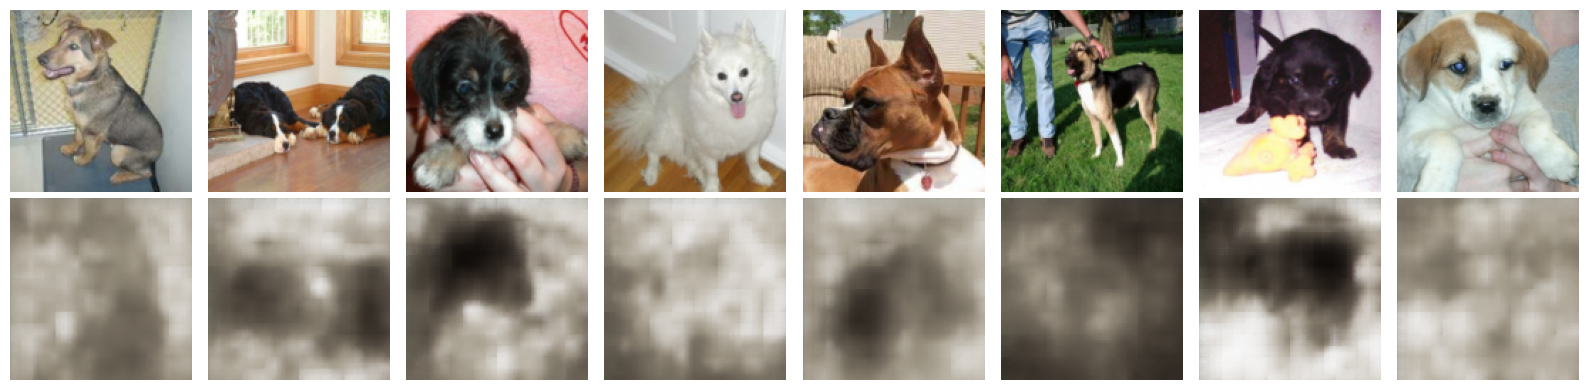

In [ ]:
show_reconstructions(val_ds, n=8)

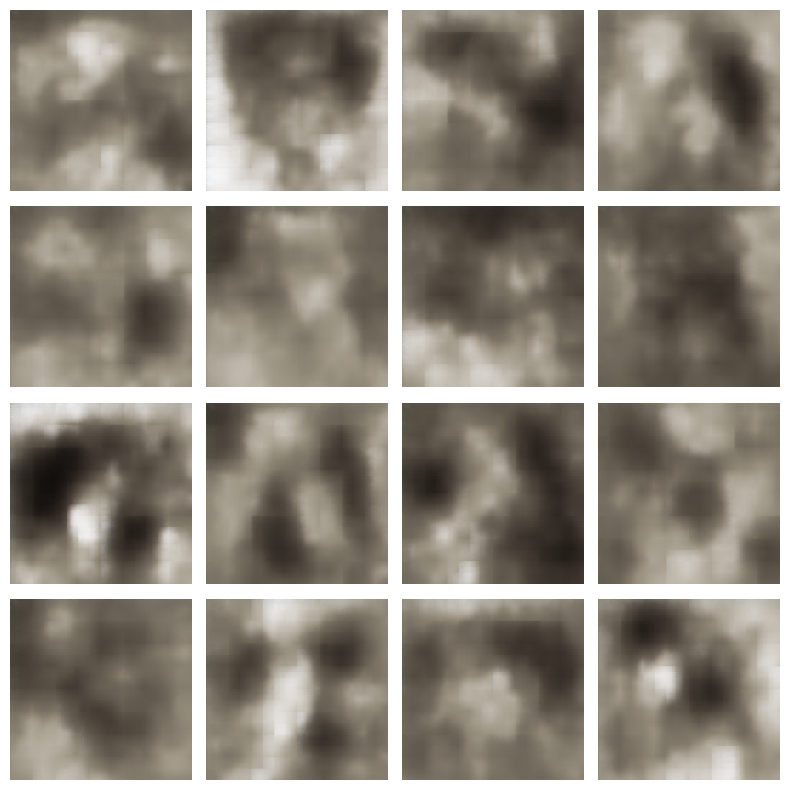

In [ ]:
show_random_images(n=16)